In [10]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
import constants

In [11]:
PATH = "/mnt/data/lorenzo/VSC_DATA/Nina"
SAMPLE_ID = "00103993-2"
MODALITY_NAME = "maldi"

OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)

In [12]:
lipidomics.preprocess_lipidomics(
    path=PATH,
    sample_id=SAMPLE_ID,
    modality_name=MODALITY_NAME,
    peak_picking = True,
    prominence = 0.01,
    window_tolerance = 10,
    dynamic_window = True,
    dynamic_window_factor = 1e6
)

Reading imzML file: /mnt/data/lorenzo/VSC_DATA/Nina/00103993-2/maldi/00103993-2.imzML, associated with IBD file /mnt/data/lorenzo/VSC_DATA/Nina/00103993-2/maldi/00103993-2.ibd
Total unique m/z values: 9187. The process will iterate as long as there are overlapping clusters.



Interpolating intensities: 100%|██████████| 2290/2290 [00:00<00:00, 4509.86it/s]


In [13]:
reference_mz = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_reference_mz.npy'))
intensities = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_intensities_matrix.npy'))

In [14]:
print(f"Reference m/z shape: {reference_mz.shape}")
print(f"Intensities shape: {intensities.shape}")

Reference m/z shape: (1019,)
Intensities shape: (52, 66, 1019)


In [15]:
alignment_engine = alignment.Aligner(PATH, SAMPLE_ID)

In [16]:
msi_image = alignment_engine._generate_msi_image(OUTPUT_PATH)

In [17]:
# Flip the image across the y-axis
#msi_image = np.flip(msi_image, axis=1)
# Flip across the x-axis
msi_image = np.flip(msi_image, axis=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


Text(0.5, 1.0, 'MSI Image for 00103993-2')

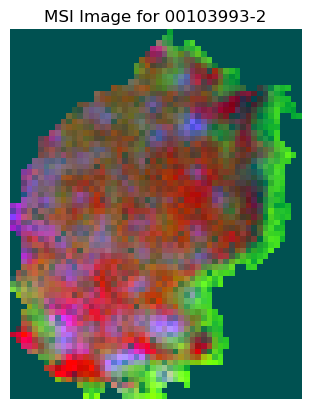

In [18]:
plt.imshow(msi_image, cmap='gray')
plt.axis('off')
plt.title(f"MSI Image for {SAMPLE_ID}")

In [19]:
import umap

# Perform UMAP dimensionality reduction
umap_model = umap.UMAP(n_components=2)
umap_embedding = umap_model.fit_transform(intensities.reshape(-1, intensities.shape[-1]))

# Plot UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=1, alpha=0.5)
plt.title(f"UMAP Embedding for {SAMPLE_ID}")

KeyboardInterrupt: 